# 🔧 Optimizing and Fine-Tuning Agents: Hands-On Workshop

**Class:** Optimizing and Fine-Tuning Agents
**Audience:** Engineering Managers & Leaders
**Duration:** ~40 minutes hands-on

---

## Workshop Overview

We'll classify **customer support tickets** into 4 categories using progressively more sophisticated approaches:

| Stage | Approach | Model | What You'll Learn |
|-------|----------|-------|-------------------|
| 1 | Zero-shot | GPT-4o-mini | Baseline — how far can a cheap model go with no examples? |
| 2 | Few-shot | GPT-4o-mini | Does adding examples improve the same model? |
| 3 | Few-shot | GPT-4o | Is a bigger model worth the cost? |
| 4 | LoRA Fine-tune | SmolLM2-1.7B | Can a tiny open-source model beat GPT after fine-tuning? |
| 5 | Compare All | — | Cost / quality / latency tradeoff analysis |

**Key Decision:** When should your team fine-tune vs. use a better prompt vs. upgrade the model?

## ⚙️ Stage 0: Environment Setup

Run the cell below to install all required packages. This takes ~2 minutes on Colab.

In [8]:
!pip install -q openai transformers datasets peft accelerate bitsandbytes trl torch scikit-learn

### Set Up OpenAI API Key

We'll try to load your key from Colab Secrets first. If that doesn't work, you can paste it manually.

**To use Colab Secrets (recommended):**
1. Click the 🔑 key icon in the left sidebar
2. Add a secret named `OPENAI_API_KEY` with your key
3. Toggle "Notebook access" on

In [3]:
!pip install -q openai transformers datasets peft accelerate bitsandbytes trl torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.2 MB/s eta 0:00:00


In [9]:
import os
from openai import OpenAI

# Try Colab Secrets first
try:
    from google.colab import userdata
    api_key = userdata.get('OPENAI_API_KEY')
    print("API key loaded from Colab Secrets")
except Exception:
    api_key = input("Enter your OpenAI API key: ")
    print("API key set manually")

client = OpenAI(api_key=api_key)

API key loaded from Colab Secrets


## 📊 The Dataset: Customer Support Tickets

We have **66 customer support tickets** across 4 categories. This is a realistic scenario — your team gets a stream of tickets and needs to auto-route them.

**Categories:** `billing`, `technical`, `account`, `shipping`

In [10]:
import random
random.seed(42)

tickets = [
    # BILLING (17 tickets)
    ("I was charged twice for my subscription this month", "billing"),
    ("Can I get a refund for the unused portion of my plan?", "billing"),
    ("My credit card was declined but I have sufficient funds", "billing"),
    ("I need to update my payment method to a new card", "billing"),
    ("The price increased without any notification", "billing"),
    ("I see an unauthorized charge on my account", "billing"),
    ("Can you explain the charges on my latest invoice?", "billing"),
    ("I cancelled but was still charged for next month", "billing"),
    ("Is there a discount for annual billing?", "billing"),
    ("My promo code isn't applying the discount correctly", "billing"),
    ("I need a receipt for my last three payments", "billing"),
    ("Why was I charged a late fee?", "billing"),
    ("Can I split my payment across two credit cards?", "billing"),
    ("The auto-renewal charged the wrong amount", "billing"),
    ("I need to dispute a charge from last month", "billing"),
    ("When will my refund be processed?", "billing"),
    ("I was charged sales tax but my state is tax-exempt", "billing"),

    # TECHNICAL (17 tickets)
    ("The app crashes every time I try to upload a file", "technical"),
    ("I'm getting a 500 error when accessing the dashboard", "technical"),
    ("The search function returns no results even for exact matches", "technical"),
    ("My data export is missing several columns", "technical"),
    ("The mobile app won't sync with the desktop version", "technical"),
    ("Page load times have been extremely slow this week", "technical"),
    ("The API is returning malformed JSON responses", "technical"),
    ("I can't connect my third-party integration", "technical"),
    ("The notification system isn't sending email alerts", "technical"),
    ("Two-factor authentication codes aren't being accepted", "technical"),
    ("The file preview feature shows a blank screen", "technical"),
    ("My scheduled reports aren't generating automatically", "technical"),
    ("The drag-and-drop feature stopped working after the update", "technical"),
    ("I'm getting timeout errors on large database queries", "technical"),
    ("The webhook endpoint isn't receiving any payloads", "technical"),
    ("Charts and graphs aren't rendering in the analytics tab", "technical"),
    ("The bulk import tool fails silently with no error message", "technical"),

    # ACCOUNT (16 tickets)
    ("I forgot my password and the reset email never arrives", "account"),
    ("I need to change the email address on my account", "account"),
    ("How do I add another user to my team account?", "account"),
    ("My account was locked after too many login attempts", "account"),
    ("I want to upgrade from the free plan to professional", "account"),
    ("Can I transfer ownership of my account to a colleague?", "account"),
    ("I need to delete my account and all associated data", "account"),
    ("How do I enable single sign-on for my organization?", "account"),
    ("My profile picture won't update", "account"),
    ("I can't access the admin panel even though I'm an admin", "account"),
    ("How do I merge two duplicate accounts?", "account"),
    ("I need to change my username", "account"),
    ("Can I temporarily deactivate my account?", "account"),
    ("My account permissions seem wrong after the migration", "account"),
    ("How do I set up role-based access for my team?", "account"),
    ("I need to export all my account data before closing it", "account"),

    # SHIPPING (16 tickets)
    ("My order hasn't arrived and it's been two weeks", "shipping"),
    ("The tracking number shows no movement for 5 days", "shipping"),
    ("I received the wrong item in my package", "shipping"),
    ("Can I change my delivery address after placing the order?", "shipping"),
    ("The package arrived damaged", "shipping"),
    ("Do you offer express shipping options?", "shipping"),
    ("I need to return an item — how do I get a shipping label?", "shipping"),
    ("My order was marked delivered but I never received it", "shipping"),
    ("Can I pick up my order from a local facility instead?", "shipping"),
    ("The shipping cost seems too high for a small item", "shipping"),
    ("I need to ship to an international address", "shipping"),
    ("My package was returned to sender — why?", "shipping"),
    ("How long does standard shipping take?", "shipping"),
    ("I want to consolidate multiple orders into one shipment", "shipping"),
    ("The delivery driver left my package in the rain", "shipping"),
    ("Can I schedule a specific delivery time window?", "shipping"),
]

# Shuffle and split 80/20
random.shuffle(tickets)
split_idx = int(len(tickets) * 0.8)
train_data = tickets[:split_idx]
test_data = tickets[split_idx:]

print(f"Total tickets: {len(tickets)}")
print(f"Training set:  {len(train_data)} tickets")
print(f"Test set:      {len(test_data)} tickets")
print(f"\nCategories: {sorted(set(cat for _, cat in tickets))}")
print(f"\nSample ticket: \"{train_data[0][0]}\" → {train_data[0][1]}")

Total tickets: 66
Training set:  52 tickets
Test set:      14 tickets

Categories: ['account', 'billing', 'shipping', 'technical']

Sample ticket: "How long does standard shipping take?" → shipping


## 🧰 Helper Functions

One classification function that works for both zero-shot and few-shot prompting.

In [11]:
import time

CATEGORIES = ["billing", "technical", "account", "shipping"]

def classify_openai(ticket_text, model="gpt-4o-mini", few_shot_examples=None):
    """Classify a support ticket using OpenAI API."""
    system_prompt = (
        "You are a customer support ticket classifier. "
        "Classify each ticket into exactly one category: billing, technical, account, or shipping. "
        "Respond with ONLY the category name, nothing else."
    )

    messages = [{"role": "system", "content": system_prompt}]

    # Add few-shot examples if provided
    if few_shot_examples:
        for example_text, example_label in few_shot_examples:
            messages.append({"role": "user", "content": example_text})
            messages.append({"role": "assistant", "content": example_label})

    messages.append({"role": "user", "content": ticket_text})

    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0,
        max_tokens=10
    )
    return response.choices[0].message.content.strip().lower()


def evaluate(predictions, actuals):
    """Calculate accuracy and per-category metrics."""
    correct = sum(p == a for p, a in zip(predictions, actuals))
    accuracy = correct / len(actuals)

    print(f"\n{'='*50}")
    print(f"Overall Accuracy: {accuracy:.1%} ({correct}/{len(actuals)})")
    print(f"{'='*50}")

    for cat in CATEGORIES:
        cat_indices = [i for i, a in enumerate(actuals) if a == cat]
        if cat_indices:
            cat_correct = sum(predictions[i] == actuals[i] for i in cat_indices)
            print(f"  {cat:12s}: {cat_correct}/{len(cat_indices)} correct")

    # Show misclassifications
    errors = [(actuals[i], predictions[i], i) for i in range(len(actuals)) if predictions[i] != actuals[i]]
    if errors:
        print(f"\nMisclassifications ({len(errors)}):")
        for actual, predicted, idx in errors[:5]:
            print(f"  \"{test_data[idx][0][:60]}...\"")
            print(f"    Expected: {actual} → Got: {predicted}")

    return accuracy

---

## 🚀 Stage 1: Zero-Shot Classification (GPT-4o-mini)

**The question:** How well does a cheap, fast model do with NO examples?

This is your team's **baseline** — the minimum effort approach.

In [12]:
print("Stage 1: Zero-Shot GPT-4o-mini")
print("=" * 50)

start = time.time()
predictions_zeroshot = []

for ticket_text, _ in test_data:
    pred = classify_openai(ticket_text, model="gpt-4o-mini")
    predictions_zeroshot.append(pred)

elapsed_zeroshot = time.time() - start
actuals = [label for _, label in test_data]

acc_zeroshot = evaluate(predictions_zeroshot, actuals)
print(f"\n⏱️  Time: {elapsed_zeroshot:.1f}s for {len(test_data)} tickets")
print(f"💰 Model: gpt-4o-mini (cheapest tier)")

Stage 1: Zero-Shot GPT-4o-mini

Overall Accuracy: 92.9% (13/14)
  billing     : 6/6 correct
  technical   : 1/1 correct
  account     : 4/5 correct
  shipping    : 2/2 correct

Misclassifications (1):
  "I can't access the admin panel even though I'm an admin..."
    Expected: account → Got: technical

⏱️  Time: 12.5s for 14 tickets
💰 Model: gpt-4o-mini (cheapest tier)


---

## 📝 Stage 2: Few-Shot Classification (GPT-4o-mini)

**The question:** Does adding 4 examples (one per category) improve results?

This is the **prompt engineering** approach — same model, better instructions.

In [13]:
# One example per category from training data
few_shot_examples = []
seen_categories = set()
for text, label in train_data:
    if label not in seen_categories:
        few_shot_examples.append((text, label))
        seen_categories.add(label)
    if len(seen_categories) == 4:
        break

print("Few-shot examples:")
for text, label in few_shot_examples:
    print(f"  [{label:10s}] \"{text[:60]}...\"")
print()

start = time.time()
predictions_fewshot_mini = []

for ticket_text, _ in test_data:
    pred = classify_openai(ticket_text, model="gpt-4o-mini", few_shot_examples=few_shot_examples)
    predictions_fewshot_mini.append(pred)

elapsed_fewshot_mini = time.time() - start

print("Stage 2: Few-Shot GPT-4o-mini")
acc_fewshot_mini = evaluate(predictions_fewshot_mini, actuals)
print(f"\n⏱️  Time: {elapsed_fewshot_mini:.1f}s for {len(test_data)} tickets")
print(f"💰 Model: gpt-4o-mini + 4 examples")

Few-shot examples:
  [shipping  ] "How long does standard shipping take?..."
  [account   ] "How do I set up role-based access for my team?..."
  [technical ] "The drag-and-drop feature stopped working after the update..."
  [billing   ] "I cancelled but was still charged for next month..."

Stage 2: Few-Shot GPT-4o-mini

Overall Accuracy: 92.9% (13/14)
  billing     : 6/6 correct
  technical   : 1/1 correct
  account     : 4/5 correct
  shipping    : 2/2 correct

Misclassifications (1):
  "I can't access the admin panel even though I'm an admin..."
    Expected: account → Got: technical

⏱️  Time: 7.9s for 14 tickets
💰 Model: gpt-4o-mini + 4 examples


---

## 💎 Stage 3: Few-Shot Classification (GPT-4o)

**The question:** Is a more expensive model worth it for this task?

Same prompt, bigger model — the **throw money at it** approach.

In [ ]:
print("Stage 3: Few-Shot GPT-4o")
print("=" * 50)

start = time.time()
predictions_fewshot_4o = []

for ticket_text, _ in test_data:
    pred = classify_openai(ticket_text, model="gpt-4o", few_shot_examples=few_shot_examples)
    predictions_fewshot_4o.append(pred)

elapsed_fewshot_4o = time.time() - start

acc_fewshot_4o = evaluate(predictions_fewshot_4o, actuals)
print(f"\n⏱️  Time: {elapsed_fewshot_4o:.1f}s for {len(test_data)} tickets")
print(f"💰 Model: gpt-4o + 4 examples (5-10x cost of mini)")

Stage 3: Few-Shot GPT-4o

Overall Accuracy: 100.0% (14/14)
  billing     : 6/6 correct
  technical   : 1/1 correct
  account     : 5/5 correct
  shipping    : 2/2 correct

⏱️  Time: 8.8s for 14 tickets
💰 Model: gpt-4o + 4 examples (5-10x cost of mini)


---

## 🔬 Stage 4: LoRA Fine-Tuning (SmolLM2-1.7B)

**The question:** Can we fine-tune a tiny open-source model to match or beat GPT?

This is the **invest upfront, save forever** approach. We'll use:
- **SmolLM2-1.7B-Instruct** — a small but capable open-source model
- **LoRA** (Low-Rank Adaptation) — trains only ~0.5% of parameters
- **4-bit quantization** — fits in Colab's free GPU

### Why this matters for leaders:
- No API costs at inference time
- Data stays on your infrastructure
- Model is yours to deploy anywhere

In [14]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_NAME = "HuggingFaceTB/SmolLM2-1.7B-Instruct"

# 4-bit quantization config — makes the model fit in ~2GB VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading model with 4-bit quantization...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

print(f"\n✅ Model loaded!")
print(f"   Parameters: {model.num_parameters():,}")
print(f"   GPU Memory: {torch.cuda.memory_allocated()/1024**3:.1f} GB")

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]


✅ Model loaded!
   Parameters: 1,711,376,384
   GPU Memory: 1.0 GB


In [15]:
# LoRA configuration — we only train small adapter matrices
lora_config = LoraConfig(
    r=16,                          # Rank — higher = more capacity, more memory
    lora_alpha=32,                 # Scaling factor (usually 2x rank)
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],  # Attention layers
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, lora_config)

trainable, total = model.get_nb_trainable_parameters()
print(f"Trainable parameters: {trainable:,} / {total:,}")
print(f"Trainable percentage: {100 * trainable / total:.2f}%")
print(f"\n💡 LoRA trains only {100 * trainable / total:.2f}% of the model!")

Trainable parameters: 6,291,456 / 1,717,667,840
Trainable percentage: 0.37%

💡 LoRA trains only 0.37% of the model!


In [16]:
# Format data for fine-tuning
def format_for_training(ticket_text, label):
    """Format as a chat-style prompt."""
    prompt = (
        f"Classify this customer support ticket into one of these categories: "
        f"billing, technical, account, shipping.\n\n"
        f"Ticket: {ticket_text}\n\n"
        f"Category: {label}"
    )
    return prompt

# Create training dataset
from datasets import Dataset

train_texts = [format_for_training(text, label) for text, label in train_data]
train_dataset = Dataset.from_dict({"text": train_texts})

print(f"Training examples: {len(train_dataset)}")
print(f"\nSample formatted input:")
print("-" * 50)
print(train_texts[0])

Training examples: 52

Sample formatted input:
--------------------------------------------------
Classify this customer support ticket into one of these categories: billing, technical, account, shipping.

Ticket: How long does standard shipping take?

Category: shipping


### Training the LoRA Adapter

This takes about **3-5 minutes** on Colab's free T4 GPU. Watch the loss decrease!

In [17]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="./lora-support-classifier",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    warmup_steps=10,
    logging_steps=5,
    save_strategy="no",
    fp16=False, # Disable fp16 to prevent the AMP gradient scaler from causing conflicts on T4
    bf16=False,
    dataset_text_field="text",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    args=training_args,
    processing_class=tokenizer,
)

print("🚀 Starting fine-tuning...")
trainer.train()
print("\n✅ Fine-tuning complete!")

Adding EOS to train dataset:   0%|          | 0/52 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/52 [00:00<?, ? examples/s]

🚀 Starting fine-tuning...


Step,Training Loss
5,2.992295
10,2.679453
15,2.117034
20,1.651676



✅ Fine-tuning complete!


### Evaluate the Fine-Tuned Model

In [18]:
def classify_finetuned(ticket_text):
    """Classify using our fine-tuned model."""
    prompt = (
        f"Classify this customer support ticket into one of these categories: "
        f"billing, technical, account, shipping.\n\n"
        f"Ticket: {ticket_text}\n\n"
        f"Category:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=False,
        )

    # Decode only the new tokens
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    result = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()

    # Extract just the category
    for cat in CATEGORIES:
        if cat in result:
            return cat
    return result.split()[0] if result else "unknown"


print("Stage 4: LoRA Fine-Tuned SmolLM2-1.7B")
print("=" * 50)

start = time.time()
predictions_lora = []

for ticket_text, _ in test_data:
    pred = classify_finetuned(ticket_text)
    predictions_lora.append(pred)

elapsed_lora = time.time() - start

acc_lora = evaluate(predictions_lora, actuals)
print(f"\n⏱️  Time: {elapsed_lora:.1f}s for {len(test_data)} tickets")
print(f"💰 Model: SmolLM2-1.7B + LoRA (self-hosted, no API cost)")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Stage 4: LoRA Fine-Tuned SmolLM2-1.7B

Overall Accuracy: 78.6% (11/14)
  billing     : 6/6 correct
  technical   : 1/1 correct
  account     : 2/5 correct
  shipping    : 2/2 correct

Misclassifications (3):
  "My account was locked after too many login attempts..."
    Expected: account → Got: billing
  "I forgot my password and the reset email never arrives..."
    Expected: account → Got: technical
  "I can't access the admin panel even though I'm an admin..."
    Expected: account → Got: technical

⏱️  Time: 27.7s for 14 tickets
💰 Model: SmolLM2-1.7B + LoRA (self-hosted, no API cost)


In [20]:
print("Stage 3: Few-Shot GPT-4o")
print("=" * 50)

start = time.time()
predictions_fewshot_4o = []

for ticket_text, _ in test_data:
    pred = classify_openai(ticket_text, model="gpt-4o", few_shot_examples=few_shot_examples)
    predictions_fewshot_4o.append(pred)

elapsed_fewshot_4o = time.time() - start

acc_fewshot_4o = evaluate(predictions_fewshot_4o, actuals)
print(f"\nTime: {elapsed_fewshot_4o:.1f}s for {len(test_data)} tickets")
print(f"Model: gpt-4o + 4 examples (5-10x cost of mini)")


Stage 3: Few-Shot GPT-4o

Overall Accuracy: 100.0% (14/14)
  billing     : 6/6 correct
  technical   : 1/1 correct
  account     : 5/5 correct
  shipping    : 2/2 correct

Time: 11.6s for 14 tickets
Model: gpt-4o + 4 examples (5-10x cost of mini)


---

## 📊 Stage 5: The Comparison — Making the Business Case

This is the slide your VP wants to see. Let's compare all approaches.

In [21]:
# Approximate costs per 1K tickets (based on typical token usage)
# ~150 tokens per ticket (prompt + completion)
results = {
    "Zero-Shot GPT-4o-mini": {
        "accuracy": acc_zeroshot,
        "time": elapsed_zeroshot,
        "cost_per_1k": "$0.02",
        "setup_effort": "None",
    },
    "Few-Shot GPT-4o-mini": {
        "accuracy": acc_fewshot_mini,
        "time": elapsed_fewshot_mini,
        "cost_per_1k": "$0.03",
        "setup_effort": "~1 hour",
    },
    "Few-Shot GPT-4o": {
        "accuracy": acc_fewshot_4o,
        "time": elapsed_fewshot_4o,
        "cost_per_1k": "$0.40",
        "setup_effort": "~1 hour",
    },
    "LoRA SmolLM2-1.7B": {
        "accuracy": acc_lora,
        "time": elapsed_lora,
        "cost_per_1k": "~$0 (self-hosted)",
        "setup_effort": "~1 week",
    },
}

print("\n" + "=" * 75)
print(f"{'Approach':<25} {'Accuracy':>10} {'Time':>10} {'Cost/1K':>15} {'Setup':>12}")
print("=" * 75)
for name, r in results.items():
    print(f"{name:<25} {r['accuracy']:>9.1%} {r['time']:>9.1f}s {r['cost_per_1k']:>15} {r['setup_effort']:>12}")
print("=" * 75)


Approach                    Accuracy       Time         Cost/1K        Setup
Zero-Shot GPT-4o-mini         92.9%      12.5s           $0.02         None
Few-Shot GPT-4o-mini          92.9%       7.9s           $0.03      ~1 hour
Few-Shot GPT-4o              100.0%      11.6s           $0.40      ~1 hour
LoRA SmolLM2-1.7B             78.6%      27.7s ~$0 (self-hosted)      ~1 week


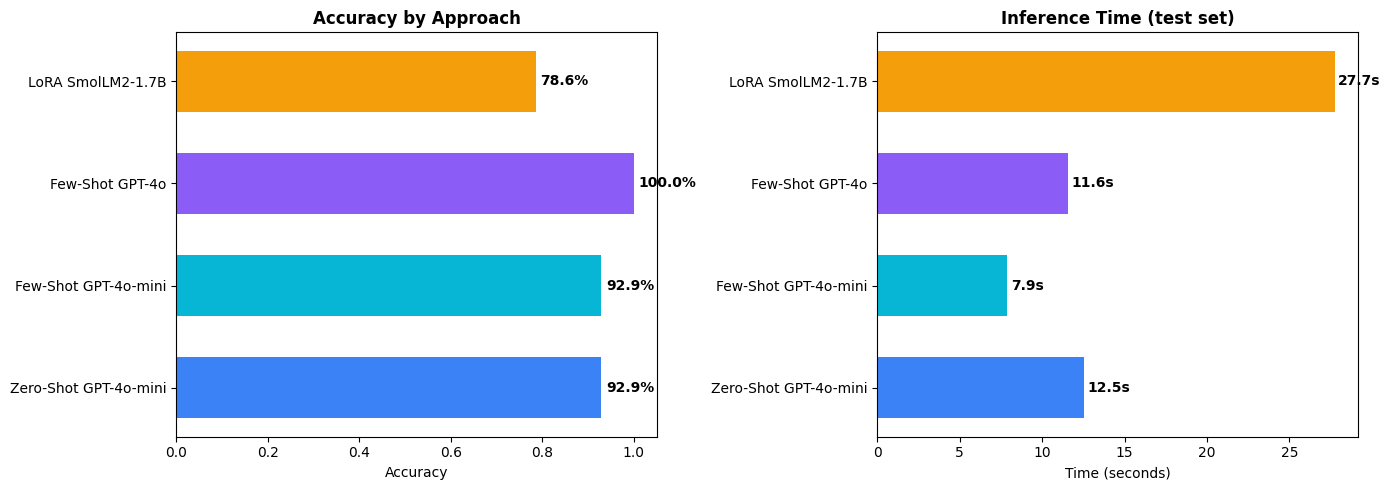


📊 Chart saved as comparison.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
accuracies = [results[n]["accuracy"] for n in names]
times = [results[n]["time"] for n in names]
colors = ["#3B82F6", "#06B6D4", "#8B5CF6", "#F59E0B"]

# Accuracy comparison
axes[0].barh(names, accuracies, color=colors, height=0.6)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Accuracy by Approach", fontweight="bold")
for i, v in enumerate(accuracies):
    axes[0].text(v + 0.01, i, f"{v:.1%}", va="center", fontweight="bold")

# Time comparison
axes[1].barh(names, times, color=colors, height=0.6)
axes[1].set_xlabel("Time (seconds)")
axes[1].set_title("Inference Time (test set)", fontweight="bold")
for i, v in enumerate(times):
    axes[1].text(v + 0.2, i, f"{v:.1f}s", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Chart saved as comparison.png")

---

## 🎁 Bonus: How Small is the LoRA Adapter?

One of the key advantages of LoRA — the adapter is tiny compared to the full model.

In [23]:
# Save and measure the LoRA adapter
model.save_pretrained("./lora-adapter")

import os
adapter_size = sum(
    os.path.getsize(os.path.join("./lora-adapter", f))
    for f in os.listdir("./lora-adapter")
    if f.endswith((".bin", ".safetensors"))
)
full_model_size = 1.7e9 * 2  # 1.7B params × 2 bytes (FP16)

print(f"Full model size:   ~{full_model_size/1e9:.1f} GB")
print(f"LoRA adapter size: {adapter_size/1e6:.1f} MB")
print(f"Compression ratio: {full_model_size/adapter_size:.0f}x smaller")
print(f"\n💡 You ship the {adapter_size/1e6:.1f}MB adapter, not the {full_model_size/1e9:.1f}GB model!")
print(f"   The base model is shared across all your fine-tuned variants.")

Full model size:   ~3.4 GB
LoRA adapter size: 12.6 MB
Compression ratio: 270x smaller

💡 You ship the 12.6MB adapter, not the 3.4GB model!
   The base model is shared across all your fine-tuned variants.


---

## 💬 Discussion Questions for Your Team

Now that you've seen all four approaches, consider these decision-making questions:

### 1. When would you choose each approach?
- **Zero-shot:** Quick prototype, low-stakes classification, testing feasibility
- **Few-shot:** Good accuracy needed, no training infrastructure, fast iteration
- **Bigger model:** Accuracy-critical, complex tasks, budget available
- **Fine-tuning:** High volume, data privacy requirements, cost optimization at scale

### 2. What's your team's break-even point?
At what ticket volume does fine-tuning's upfront cost pay for itself vs. API calls?

### 3. Hidden costs to consider:
- **API approach:** Ongoing per-token costs, vendor dependency, data leaving your infrastructure
- **Fine-tuning:** Data curation time, GPU costs, model maintenance, evaluation infrastructure

### 4. What would you recommend for:
- A startup processing 100 tickets/day?
- An enterprise processing 100,000 tickets/day?
- A healthcare company with strict data privacy requirements?

---

**🎯 Key Takeaway:** There's no universally "best" approach. The right choice depends on your volume, budget, accuracy requirements, and data sensitivity constraints. The best engineering leaders match the solution to the problem — not the other way around.